### Assignment #8 Implementation of online regressor

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator
from sklearn.metrics import log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
class SGDRegressor(BaseEstimator):
    def __init__(self, eta=1e-3, n_epochs=3):
        self.eta = eta
        self.n_epochs = n_epochs
        self.mse_ = []
        self.weights_ = []

    def fit(self, X, y):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        w = np.zeros(X.shape[1])
        
        for _ in range(self.n_epochs):
            for i in range(X.shape[0]):
                prediction = np.dot(X[i], w)
                error = y[i] - prediction
                w += self.eta * error * X[i]
                
            self.weights_.append(w.copy())
            self.mse_.append(mean_squared_error(y, np.dot(X, w)))
            
        self.w_ = self.weights_[np.argmin(self.mse_)]
        return self

    def predict(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        return np.dot(X, self.w_)

In [4]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [5]:
data_demo = pd.read_csv(DATA_PATH + "weights_heights.csv")

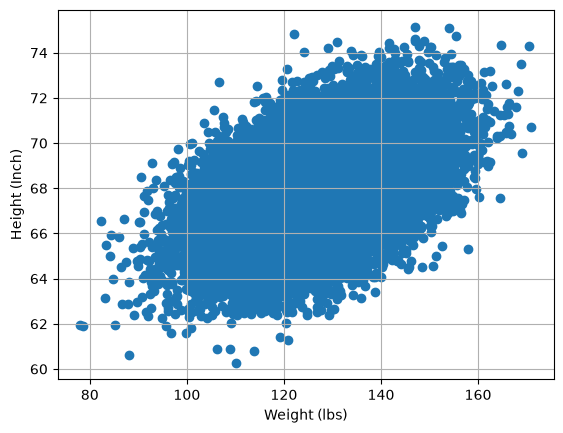

In [6]:
plt.scatter(data_demo["Weight"], data_demo["Height"])
plt.xlabel("Weight (lbs)")
plt.ylabel("Height (Inch)")
plt.grid();

In [7]:
X, y = data_demo["Weight"].values, data_demo["Height"].values

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=17
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape([-1, 1]))
X_valid_scaled = scaler.transform(X_valid.reshape([-1, 1]))

Train created SGDRegressor with (X_train_scaled, y_train) data. Leave default parameter values for now.

In [12]:
sgd_regressor = SGDRegressor()
sgd_regressor.fit(X_train_scaled, y_train)

,eta,0.001
,n_epochs,3
Name,Type,Value
mse_,list,"[2.71865292491174, 2.7186530859634357, 2.718653085963437]"
w_,"ndarray[float64](2,)","[68.04, 0.91]"
weights_,list,"[array([68.037... 0.91137808]), array([68.037... 0.91137811]), array([68.037... 0.91137811])]"


Draw a chart with training process – dependency of mean squared error from the i-th SGD iteration number.

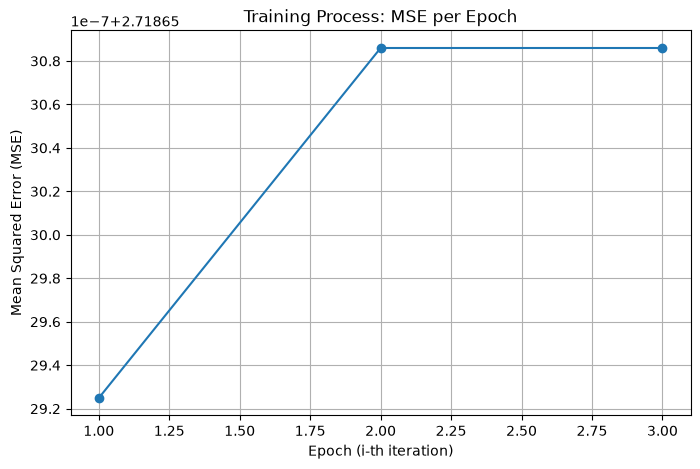

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(sgd_regressor.mse_) + 1), sgd_regressor.mse_, marker='o', linestyle='-')
plt.title('Training Process: MSE per Epoch')
plt.xlabel('Epoch (i-th iteration)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

Print the minimal value of mean squared error and the best weights vector.

In [14]:
print("Minimal MSE:", min(sgd_regressor.mse_))
print("Best weights vector:", sgd_regressor.w_)

Minimal MSE: 2.71865292491174
Best weights vector: [68.0379205   0.91137808]


Draw chart of model weights( w0 and w1 ) behavior during training.

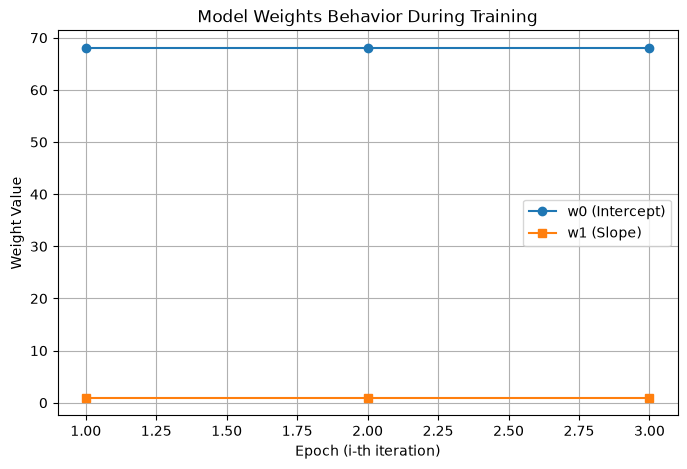

In [15]:
weights_array = np.array(sgd_regressor.weights_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(weights_array) + 1), weights_array[:, 0], label='w0 (Intercept)', marker='o')
plt.plot(range(1, len(weights_array) + 1), weights_array[:, 1], label='w1 (Slope)', marker='s')
plt.title('Model Weights Behavior During Training')
plt.xlabel('Epoch (i-th iteration)')
plt.ylabel('Weight Value')
plt.legend()
plt.grid(True)
plt.show()

Make a prediction for hold-out set (X_valid_scaled, y_valid) and check MSE value.

In [16]:
y_pred = sgd_regressor.predict(X_valid_scaled)
valid_mse = mean_squared_error(y_valid, y_pred)
print("Hold-out MSE:", valid_mse)

Hold-out MSE: 2.6758567247697678


Do the same thing for LinearRegression class from sklearn.linear_model. Evaluate MSE for hold-out set.

In [19]:
sgd_holdout_mse = mean_squared_error(y_valid, sgd_regressor.predict(X_valid_scaled))

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
linreg_holdout_mse = mean_squared_error(y_valid, linreg.predict(X_valid_scaled))

In [20]:
try:
    assert (sgd_holdout_mse - linreg_holdout_mse) < 1e-4
    print("Correct!")
except AssertionError:
    print(
        "Something's not good.\n Linreg's holdout MSE: {}"
        "\n SGD's holdout MSE: {}".format(linreg_holdout_mse, sgd_holdout_mse)
    )

Something's not good.
 Linreg's holdout MSE: 2.6708307676676344
 SGD's holdout MSE: 2.6758567247697678
